In [1]:
import os, sys
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import gridspec
import numpy as np
from scipy.optimize import minimize
from scipy.stats import chi2
from tqdm import *

from grf.grf import FIRAS
from grf.units import *
from grf.pk_interp import PowerSpectrumGridInterpolator

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2

/tmp/ipykernel_51440/895800495.py:18: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


# FIRAS data checks and plot

In [2]:
# Plot parameters

from plot_params import params

for k, v in params.items():
    if k in pylab.rcParams:
        try:
            pylab.rcParams[k] = v
        except (ValueError, TypeError):
            pass

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
# Where to save plots
plots_dir = "../paper/draft-letter/plots/"

## FIRAS data checks

In [4]:
pspec = PowerSpectrumGridInterpolator("nonlin_matter_bj")

In [5]:
firas = FIRAS(pspec)

In [6]:
chi2_null = minimize(firas.chi2_FIRAS,x0=[2.725],args=(0, np.ones_like(firas.omega_FIRAS)), method='Powell')

In [7]:
chi2_null.x

array([2.72501612])

In [8]:
ndof = len(firas.d) - 1

print('chi2 is', chi2_null.fun)
print('chi2 / ndof is', chi2_null.fun / ndof)

chi2 is 48.19672388440352
chi2 / ndof is 1.1475410448667505


In [9]:
chi2.ppf(q=0.95, df=ndof)

58.12403768086803

In [10]:
# Amazing!
(firas.d - firas.B_CMB(firas.omega_FIRAS, chi2_null.x)  / (1e6 * Jy)) * 1e3 / firas.resid

array([1.01859719, 1.01219076, 1.00665937, 0.96947154, 0.99214745,
       0.99333804, 1.01169956, 0.99478963, 0.97820663, 0.98441193,
       1.39763437, 0.95627029, 1.03539685, 0.93132578, 0.90965345,
       1.04189894, 0.91012727, 0.96399756, 0.94892634, 1.01679609,
       1.01600409, 0.99166355, 0.91752159, 1.12357595, 0.91454267,
       1.02221855, 1.00214995, 0.99539554, 1.01021675, 0.98502828,
       0.97942199, 0.92540091, 0.97359245, 1.01144427, 0.97696507,
       0.98370209, 1.01099056, 0.94466421, 1.00737461, 0.98468032,
       1.00800534, 1.00442703, 1.00053248])

In [11]:
# Get disappearance probabilities for benchmark point
p1 = 1 - firas.P_tot_perturb(firas.omega_FIRAS, 6e-6, 4e-15 * eV)[2]

/home/jortecal/GitHub/TMS/DarkPhoton/notebooks/../grf/grf.py:179: RuntimeWarning: invalid value encountered in sqrt
  m_A_ary = np.nan_to_num(np.sqrt(self.m_A_sq(
/home/jortecal/GitHub/TMS/DarkPhoton/notebooks/../grf/grf.py:185: RuntimeWarning: invalid value encountered in sqrt
  def m_A_sq(z): return np.nan_to_num(np.sqrt(self.m_A_sq(
/home/jortecal/GitHub/TMS/DarkPhoton/notebooks/../grf/grf.py:375: RuntimeWarning: invalid value encountered in log
  pdf_ary = 1 / np.sqrt(2 * np.pi * sigma_LN_sq_ary) * np.exp(-(np.log(1 / b * (m_Ap ** 2 / m_A_sq + b - 1)) +
/home/jortecal/GitHub/TMS/DarkPhoton/notebooks/../grf/grf.py:378: RuntimeWarning: invalid value encountered in log
  dP_dz_ary = 1 / np.sqrt(2 * np.pi * sigma_LN_sq_ary) * np.exp(-(np.log(1 / b * (m_Ap ** 2 / m_A_sq + b - 1)) + sigma_LN_sq_ary / 2.)


## FIRAS blackbody plot (Fig. 4)

/tmp/ipykernel_51440/482609975.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


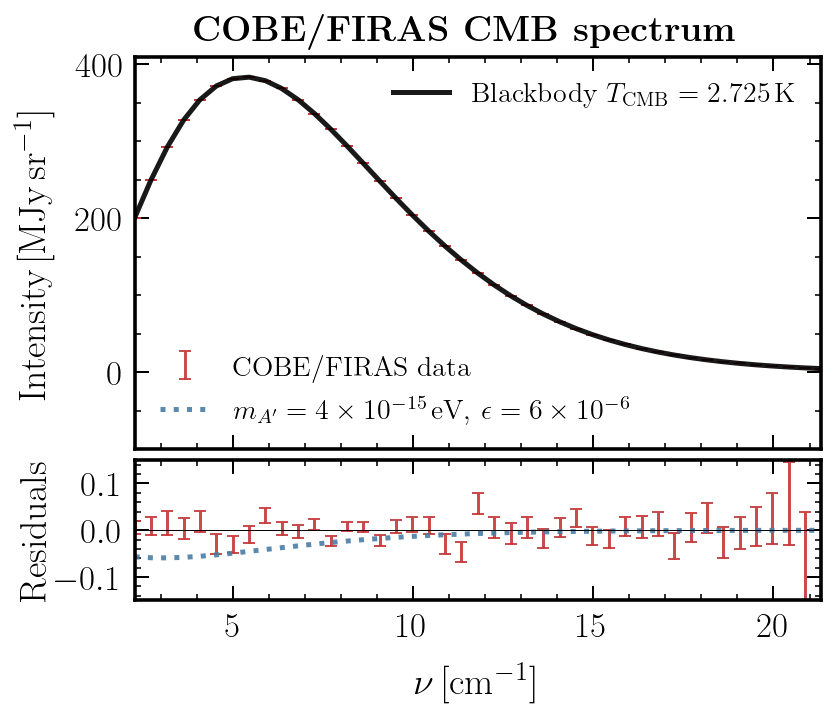

In [12]:
gs = gridspec.GridSpec(2, 1, height_ratios=[2.8, 1], hspace=0.04)

# Top plot

ax0 = plt.subplot(gs[0])

line2 = ax0.errorbar(firas.df['freq'], firas.d, yerr=firas.df['uncert'] / 1e3, c=cols_default[0], fmt='none', capsize=3, capthick=1, elinewidth=1.5, label='COBE/FIRAS data')
line1, = ax0.plot(firas.df['freq'], firas.B_CMB(firas.omega_FIRAS, chi2_null.x)   / (1e6 * Jy), c='k', ls='-', label='Blackbody $T_{\mathrm{CMB}} = 2.725\,\mathrm{K}$')

ax0.set_xlim(np.min(firas.df['freq']), np.max(firas.df['freq']))
ax0.set_ylim(-50, 420)

ax0.set_ylabel(r"Intensity\,[MJy\,sr$^{-1}$]")
line3, = ax0.plot([],[], c=cols_default[1], ls=':', label=r'$m_{A^\prime}=4\times 10^{-15}$\,eV, $\epsilon=6\times 10^{-6}$')

ax0.set_ylim(-100, 410)
first_legend = plt.legend(handles=[line1], loc='upper right', fontsize=14)

# Add the legend manually to the current Axes.
plt.gca().add_artist(first_legend)

# Create another legend for the second line.
plt.legend(handles=[line2, line3], loc='lower left', fontsize=14, handlelength=1.8)

# Bottom plot

ax1 = plt.subplot(gs[1])

ax1.errorbar(firas.df['freq'], firas.d - firas.B_CMB(firas.omega_FIRAS, chi2_null.x)   / (1e6 * Jy), yerr=firas.df['uncert'] / 1e3, c=cols_default[0], fmt='none', capsize=3, capthick=1, elinewidth=1.5)
ax1.plot(firas.df['freq'], p1 * firas.B_CMB(firas.omega_FIRAS, chi2_null.x)   / (1e6 * Jy) - firas.B_CMB(firas.omega_FIRAS, chi2_null.x)   / (1e6 * Jy), c=cols_default[1], ls=':')
ax1.axhline(0., c='k', ls='-', lw=0.5)
ax1.set_xlim(np.min(firas.df['freq']), np.max(firas.df['freq']))
ax1.set_ylim(-0.15, 0.15)

ax1.set_ylabel("Residuals", labelpad=0.1)
ax1.set_xlabel(r"$\nu\,[\mathrm{cm}^{-1}]$")

plt.suptitle(r"\bf{COBE/FIRAS CMB spectrum}", y=0.94, fontsize=18)

plt.tight_layout()

plt.savefig(plots_dir + "firas_bb.pdf", bbox_inches='tight')